# Installation

In [1]:
!pip install -r requirements.txt

# Modules
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import os

# Fonctions
from download_dataa import download_all
from data_vis import( 
    plot_all_returns, 
    plot_returns_separately, 
    plot_single_series, 
    build_price_dataframe, 
    plot_all_prices, 
    plot_prices_separately, 
    plot_gold_price_actual_vs_predicted_test, 
    plot_gold_returns_actual_vs_predicted_test, 
    plot_gold_var_residuals,
    plot_gold_var_squared_residuals,
    plot_gold_var_squared_residuals_acf
)
from data_vis import (
    load_and_merge_data,
    plot_timeseries_multi,
    plot_correlation_heatmap,
    plot_geopolitical_timeline,
    plot_normalized_evolution,
    plot_scatter_matrix,
    plot_gpr_choropleth,
)
from time_series_tests import adf_test_single_series, adf_test_all_var_series, print_adf_conclusion, build_var_stability_table, is_var_stable, print_var_stability_conclusion, residual_serial_correlation_test, get_residual_serial_correlation_summary, print_residual_serial_correlation_conclusion, get_granger_test_summary, granger_tests_for_gold, print_granger_conclusion,print_arch_lm_conclusion
from modele import (
    get_var_model_info,
    get_var_summary,
    rolling_var_lag_selection,
    choose_final_lag_from_rolling,
    run_full_var_train_test_pipeline,
    run_reduced_var_train_test_pipeline,
    print_final_lag_selection,
    extract_gold_var_residuals,
    build_garchx_train_dataset,
    fit_garch11_student,
    fit_garch11x_student,
    get_garch_model_info
   
)
from preprocessing import prepare_var_dataset, load_market_data, clean_all_market_data, prepare_daily_macro_exog, split_macro_exog_train_test_by_date

# Import des donnees

In [ ]:
download_all()

  Téléchargement des données
  Période : 2005-01-01 → 2026-04-20

── 1/3  Yahoo Finance ──────────────────────────────
  [gold] Téléchargement Yahoo Finance (GC=F)...
  [gold] ✓ 5351 observations → data/gold.csv
  [dxy] Téléchargement Yahoo Finance (DX-Y.NYB)...
  [dxy] ✓ 5362 observations → data/dxy.csv
  [sp500] Téléchargement Yahoo Finance (^GSPC)...
  [sp500] ✓ 5356 observations → data/sp500.csv
  [vix] Téléchargement Yahoo Finance (^VIX)...
  [vix] ✓ 5356 observations → data/vix.csv

── 2/3  FRED — CPI ─────────────────────────────────
  [cpi] Téléchargement FRED (série CPIAUCSL)...
  [cpi] ✓ 254 observations → data/cpi.csv

── 3/3  GPR — Iacoviello ───────────────────────────
  [gpr] Scraping de la page Iacoviello...
  [gpr] Fichier détecté : https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls
  [gpr] ✓ Fichier brut sauvegardé → data/gpr_raw.xls

  ✓ Tous les fichiers sont dans le dossier data/


# Préprocessing 

In [3]:
# ============================================================
# 2. Chargement & fusion
# ============================================================
 
df = load_and_merge_data()
 
print(f"\nDataFrame fusionné : {df.shape[0]} observations × {df.shape[1]} variables")
print(f"Période            : {df.index[0].date()} → {df.index[-1].date()}")
print(f"\n{df.tail(3).to_string()}\n")

Chargement des données...
GPR chargé depuis l'onglet 'Sheet1' (495 obs)
DataFrame fusionné : 254 observations, 6 variables
Période : 2005-01-31 → 2026-03-31

DataFrame fusionné : 254 observations × 6 variables
Période            : 2005-01-31 → 2026-03-31

                   gold        dxy        sp500        vix      cpi         gpr
date                                                                           
2026-01-31  4713.899902  96.989998  6939.029785  17.440001  326.588  167.800201
2026-02-28  5230.500000  97.610001  6878.879883  19.860001  327.460  121.616882
2026-03-31  4647.600098  99.959999  6528.520020  25.250000  330.293  297.269806



In [4]:
var_df = prepare_var_dataset(data_dir="data")

-> Ici on charge les csv, on nettoie les bdd pour avoir les mêmes colonnes, on applique le log aux returns de la série pour la stationarisé, on fusionne ensuite toutes les bdd avec date et enfin on enlève les NaN créer par les returns 

# Visualisation

In [ ]:
# 3.1 — Séries temporelles (6 panneaux, base 100)
plot_timeseries_multi(df)

[Plotly] Séries temporelles → figures/timeseries_multi.html


In [6]:
# 3.2 — Heatmap des corrélations (niveaux + différences premières)
plot_correlation_heatmap(df)

[Plotly] Heatmap corrélations → figures/correlation_heatmap.html


In [7]:
# 3.3 — Timeline géopolitique (or + GPR + événements annotés)
plot_geopolitical_timeline(df)

[Plotly] Timeline géopolitique → figures/geopolitical_timeline.html


In [8]:
# 3.4 — Évolution normalisée sur un seul graphique (style cluster lines)
plot_normalized_evolution(df)

[Plotly] Évolution normalisée → figures/normalized_evolution.html


In [9]:
# 3.5 — Scatter matrix complète (pairplot coloré par niveau de l'or)
plot_scatter_matrix(df)

[Plotly] Scatter matrix → figures/scatter_matrix.html


In [20]:
raw_data = load_market_data()
cleaned_data = clean_all_market_data(raw_data)
cleaned_data.keys()
gold = cleaned_data["gold"]
dxy = cleaned_data["dxy"]
sp500 = cleaned_data["sp500"]
vix = cleaned_data["vix"]
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
df = gold.merge(dxy, on="date", how="inner") \
         .merge(sp500, on="date", how="inner") \
         .merge(vix, on="date", how="inner")

df = df.sort_values("date")

In [19]:
for col in ["gold_price", "sp500_price", "dxy_price", "vix_price"]:
    df_norm[col] = df_norm[col] / df_norm[col].iloc[0] * 100

plt.figure()
sns.lineplot(data=df_norm, x="date", y="gold_price", label="Gold")
sns.lineplot(data=df_norm, x="date", y="sp500_price", label="SP500")
sns.lineplot(data=df_norm, x="date", y="dxy_price", label="DXY")
sns.lineplot(data=df_norm, x="date", y="vix_price", label="VIX")
plt.title("Comparaison des actifs (base 100)")
plt.ylabel("Base 100")
plt.show()
# J'ai fais une fonctions qui fais ça : plot_all_prices()


NameError: name 'df_norm' is not defined

In [18]:
plt.figure()
sns.lineplot(data=df_norm, x="date", y="gold_price", label="Gold")
sns.lineplot(data=df_norm, x="date", y="vix_price", label="VIX")
plt.title("Or vs VIX (actif refuge ?)")
plt.show()


NameError: name 'df_norm' is not defined

<Figure size 1200x600 with 0 Axes>

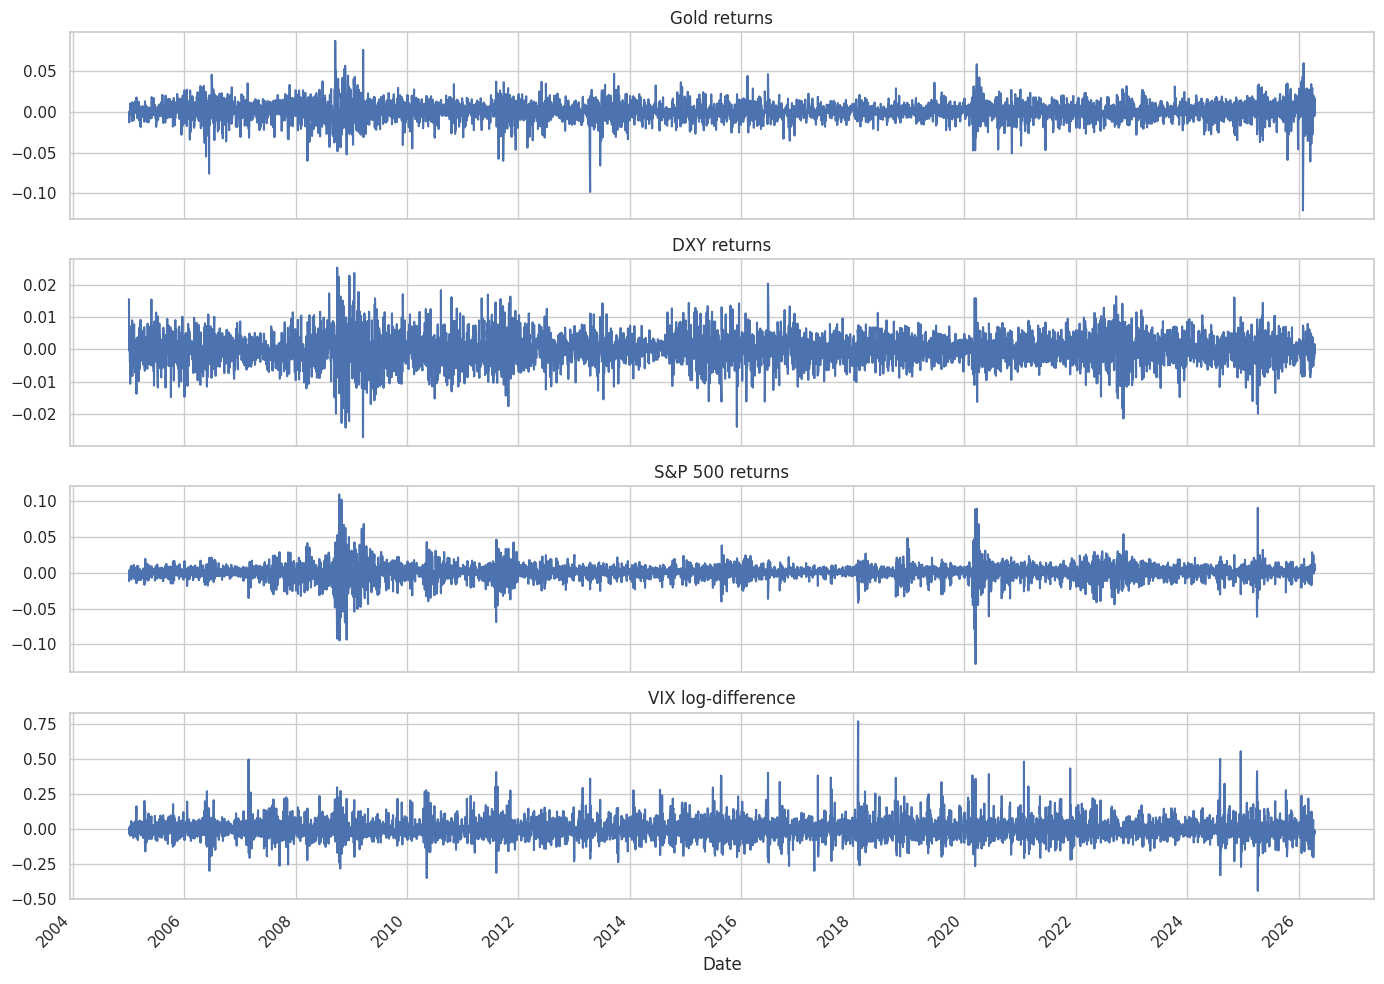

In [22]:
plot_returns_separately(var_df)

# TEST sur les séries

Test ADF qui vérifie la stationarité des séries (returns)

In [ ]:
adf_results = adf_test_all_var_series(var_df)
adf_results 

On a donc des p-value > 0.05 donc l'ensemble des séries sont stationaires 

# VAR

## Modélisation 

In [ ]:
full_var_results = run_full_var_train_test_pipeline(
    var_df=var_df,
    price_df=price_df,
    train_start="2005-01-01",
    train_end="2020-12-31",
    test_start="2021-01-01",
    test_end="2025-12-31",
    window_years=7,
    step_years=2,
    max_lag=10,
    price_reconstruction_mode="dynamic"
)
plot_gold_price_actual_vs_predicted_test(full_var_results["gold_price_forecast_df"])

In [ ]:
reduced_var_results = run_reduced_var_train_test_pipeline(
    var_df=var_df,
    price_df=price_df,
    train_start="2005-01-01",
    train_end="2020-12-31",
    test_start="2021-01-01",
    test_end="2025-12-31",
    window_years=7,
    step_years=2,
    max_lag=10
)
print_final_lag_selection(reduced_var_results["final_lag_dict"])
reduced_var_results["lag_summary_df"]
reduced_var_results["final_lag"]
print(get_var_summary(reduced_var_results["fitted_model"]))
get_var_model_info(reduced_var_results["fitted_model"])
reduced_var_results["gold_price_forecast_df"].head()
plot_gold_price_actual_vs_predicted_test(reduced_var_results["gold_price_forecast_df"])

In [ ]:
full_var_results["gold_price_forecast_df"].head(20)

## Test sur le VAR

TEST de la stabilité du VAR 

In [ ]:
fitted_model = full_var_results["fitted_model"]
print_var_stability_conclusion(fitted_model)

Le VAR est donc stable 

TEST d'autocorrélation des résidus 

In [ ]:
print_residual_serial_correlation_conclusion(fitted_model, nlags=12)

Bien que le VAR(3) soit stable, le test de Portmanteau rejette nettement l’hypothèse d’absence d’autocorrélation résiduelle. Cela suggère que la structure dynamique du système n’est pas entièrement capturée par trois retards

TEST de causalité de granger 

In [ ]:
granger_results = granger_tests_for_gold(fitted_model)
granger_results

Ainsi, à fréquence journalière, les variations du dollar et du stress de marché contiennent de l’information utile pour prévoir l’or, davantage que les rendements actions eux-mêmes.

Retrait du Sp500

In [ ]:
fitted_model = reduced_var_results["fitted_model"]
print_var_stability_conclusion(fitted_model)

In [ ]:
print_residual_serial_correlation_conclusion(fitted_model, nlags=12)

In [ ]:
granger_results_reduced = pd.DataFrame([
    get_granger_test_summary(fitted_model, caused="gold_ret", causing="dxy_ret"),
    get_granger_test_summary(fitted_model, caused="gold_ret", causing="vix_ret"),
])

granger_results_reduced

Le retrait du S&P 500 améliore la qualité du VAR et confirme que les déterminants les plus utiles pour l’or sont le dollar et le VIX. En revanche, le test de whiteness restant rejeté, le modèle à 3 variables ne constitue pas encore une spécification pleinement satisfaisante du point de vue dynamique.


# VAR-GARCH-X 

Au vu de nos résultats, un VAR-GARCH-X se justifie car le DXY et le VIX ont un pouvoir prédictif sur les rendements de l’or, tandis que la dynamique résiduelle restante suggère qu’il faut modéliser non seulement la moyenne conditionnelle, mais aussi la volatilité conditionnelle.

## Préprocessing

In [ ]:
gold_resid_train_df = extract_gold_var_residuals(reduced_var_results["fitted_model"])
plot_gold_var_residuals(gold_resid_train_df)
plot_gold_var_squared_residuals(gold_resid_train_df)
plot_gold_var_squared_residuals_acf(gold_resid_train_df, lags=30)

In [ ]:
print_arch_lm_conclusion(gold_resid_train_df, nlags=12)

Les résidus de l’équation de l’or issus du VAR présentent un effet ARCH significatif. Le VAR ne suffit donc pas à décrire entièrement la dynamique de la série. Il est pertinent de compléter la modélisation de la moyenne par un modèle GARCH-X afin de capturer la variance conditionnelle résiduelle.

## Modéliastion du VAR-GARCH-X

In [ ]:
macro_exog_df = prepare_daily_macro_exog(
    data_dir="data",
    daily_calendar_df=var_df[["date"]]
)

macro_train_df, macro_test_df = split_macro_exog_train_test_by_date(
    macro_exog_df=macro_exog_df,
    train_start="2005-01-01",
    train_end="2020-12-31",
    test_start="2021-01-01",
    test_end="2025-12-31"
)

garchx_train_df = build_garchx_train_dataset(
    gold_resid_train_df=gold_resid_train_df,
    macro_train_df=macro_train_df
)

VAR-GARCH(1,1)

In [ ]:
garch11_student_res = fit_garch11_student(
    gold_resid_train_df=gold_resid_train_df
)

get_garch_model_info(garch11_student_res)

VAR-GARCH-X

In [ ]:
garch11x_student_res = fit_garch11x_student(
    garchx_train_df=garchx_train_df
)

get_garch_model_info(garch11x_student_res)

Comparaison des deux modèles

In [ ]:
comparison_df = pd.DataFrame([
    get_garch_model_info(garch11_student_res),
    get_garch_model_info(garch11x_student_res)
])

comparison_df

## Prédiction 

## Test sur le VAR-GARCH-X